# House Prices Project

**Dataset**: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

**Goal**: Predict the sale price of houses using statistical and machine learning methods.


---
## Setup and Imports

In [27]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Add your additional imports as needed
# from sklearn...
# import statsmodels.api as sm
# import torch

pd.set_option('display.max_columns', 100)
%matplotlib inline

---
## Load Data

In [6]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print(f'Training set: {train.shape[0]} rows, {train.shape[1]} columns')
print(f'Test set: {test.shape[0]} rows, {test.shape[1]} columns')

train.head()

Training set: 1460 rows, 81 columns
Test set: 1459 rows, 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


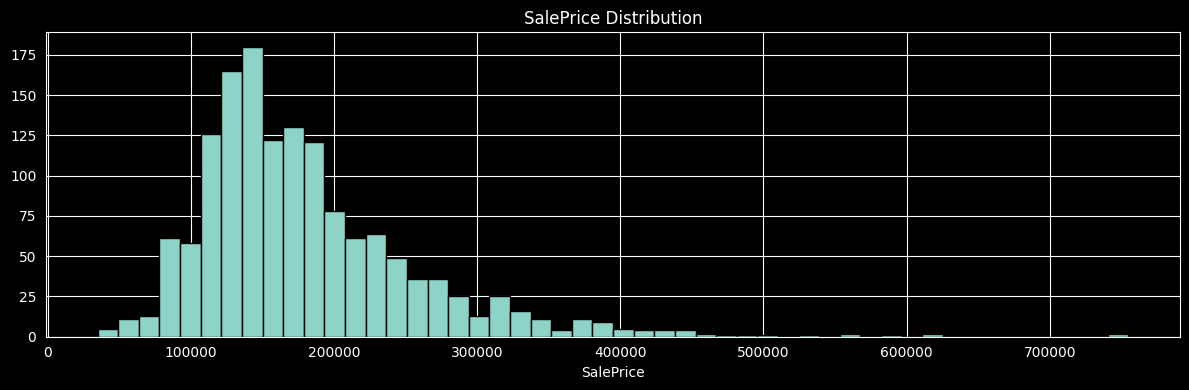

Skewness: 1.883


In [3]:
# Explore the target variable
print(train['SalePrice'].describe())

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(train['SalePrice'], bins=50, edgecolor='black')
axes.set_title('SalePrice Distribution')
axes.set_xlabel('SalePrice')
plt.tight_layout()
plt.show()

print(f'Skewness: {train["SalePrice"].skew():.3f}')

The data is heavily skewed, what kind of transformation can we apply to make it more normal?

---
## Part 0: Cleanning data

In [7]:
nrow = len(train)
stats_list = []

for col in train.columns:
    n = train[col].isnull().sum()
    ratio_text = f"{n} / {nrow}"
    percentage = (n / nrow) * 100

    stats_list.append({
        'Columns': col,
        'Format (n/nrow)': ratio_text,
        'Missing (%)': round(percentage, 2)
    })

df_stats = pd.DataFrame(stats_list)

print("Columns composition:")
print(df_stats.sort_values(by='Missing (%)', ascending=False).to_string(index=False))

for col in train.columns:
        train[col] = train[col].fillna("None")

# --- VÉRIFICATION APRÈS ---
print("\n--- Results after modifications ---")
total_nans_remaining = train.isnull().sum().sum()
print(f"Amount of empty cells after modifications : {total_nans_remaining}")

Columns composition:
      Columns Format (n/nrow)  Missing (%)
       PoolQC     1453 / 1460        99.52
  MiscFeature     1406 / 1460        96.30
        Alley     1369 / 1460        93.77
        Fence     1179 / 1460        80.75
   MasVnrType      872 / 1460        59.73
  FireplaceQu      690 / 1460        47.26
  LotFrontage      259 / 1460        17.74
   GarageQual       81 / 1460         5.55
 GarageFinish       81 / 1460         5.55
   GarageType       81 / 1460         5.55
  GarageYrBlt       81 / 1460         5.55
   GarageCond       81 / 1460         5.55
 BsmtFinType2       38 / 1460         2.60
 BsmtExposure       38 / 1460         2.60
     BsmtCond       37 / 1460         2.53
     BsmtQual       37 / 1460         2.53
 BsmtFinType1       37 / 1460         2.53
   MasVnrArea        8 / 1460         0.55
   Electrical        1 / 1460         0.07
   Condition2        0 / 1460         0.00
     BldgType        0 / 1460         0.00
 Neighborhood        0 / 1460    

- The following columns have a lot of missing values : PoolQC, MiscFeature, Alley, Fence and FireplaceQu.
- Since we lack data on those columns, they might be less significant but this will have to be proved. For now, we change the missing values to "None" for all the columns (categorical and numerical). We apply "None" to numerical variables as well acknowledging that using 0 for numerical columns can be inappropriate in some cases (For example in LotArea which can not logically have a base value of zero). 

---
## Part 1: Classical Statistical Inference

Apply basic statistical methods to explore the data:
- **Sample mean and variance** of `SalePrice` and key features
- **Confidence intervals** for the mean SalePrice
- **Hypothesis testing** — e.g. is the mean SalePrice significantly different from \$180,000? 
- Visualize distributions and support your conclusions with plots

In [11]:
#Descriptive statistics for the target variable
sp_mean = train['SalePrice'].mean()
sp_var = train['SalePrice'].var()
print(f'Mean: {sp_mean:,.2f} $, Variance: {sp_var:.3e}')
#add the skewness and kurtosis
print(f'Skewness: {train["SalePrice"].skew():.3f}')
print(f'Kurtosis: {train["SalePrice"].kurtosis():.3f}')

Mean: 180,921.20 $, Variance: 6.311e+09
Skewness: 1.883
Kurtosis: 6.536


In [15]:
# Transforming prices into logs to have a normal distribution. Adding them to the train dataframe
train["SalePrice_log"] = np.log(train['SalePrice'])
sales_price = train['SalePrice_log']

# mean, variance, SD
mean_sales_price = np.mean(sales_price)
n = len(sales_price)
var_sales_price = sum((x - mean_sales_price)**2 for x in sales_price)/(n-1)
std_sales_price = np.sqrt(var_sales_price)

print(sales_price.describe())

print(f'Skewness: {sales_price.skew():.3f}')
print(f'Kurtosis: {sales_price.kurtosis():.3f}')


count    1460.000000
mean       12.024051
std         0.399452
min        10.460242
25%        11.775097
50%        12.001505
75%        12.273731
max        13.534473
Name: SalePrice_log, dtype: float64
Skewness: 0.121
Kurtosis: 0.810


- We went from a skewness of 1.88 for the raw SalePrice to a skewness of 0.12 for the logarithmic SalePrice (reference value in a Normal distribution: 0)
- Kurtosis passed from 6.54 to 0.8 (reference value in a Normal distribution: 3)
- This indicates that the log transformation has significantly improved the normality of the SalePrice variable, making it more suitable for modeling techniques that assume normality.

In [29]:
# Shapiro test doesn't properly work on large samples
print(stats.shapiro(sales_price))

random.seed(20)
# Shapiro test on a random sample from sales_log with n=100
print(stats.shapiro(sales_price.sample(50)))
print(stats.shapiro(sales_price.sample(50)))
print(stats.shapiro(sales_price.sample(50)))
print(stats.shapiro(sales_price.sample(100)))

ShapiroResult(statistic=np.float64(0.9912067503807811), pvalue=np.float64(1.1490615527264654e-07))
ShapiroResult(statistic=np.float64(0.9683648675197852), pvalue=np.float64(0.19842413133958098))
ShapiroResult(statistic=np.float64(0.9407125869073987), pvalue=np.float64(0.014377454930721192))
ShapiroResult(statistic=np.float64(0.9582976737897198), pvalue=np.float64(0.0754321615256602))
ShapiroResult(statistic=np.float64(0.9615697056200319), pvalue=np.float64(0.005211400673238082))


At first we ran a Shapiro test on the entire sample, which retuned a negative result (p-value < 0.05) suggesting the logarithmic transformation didn't normalize the data. Knowing that Shapiro's test isn't suitable for large samples, we ran it again on small randomized samples and we obtained mixed results.
Overall it doesn't look reliable to conclude anything about the normality of the distribution, so we opted for a QQ-plot and an histogram to back up the effectivenss of the normalization.

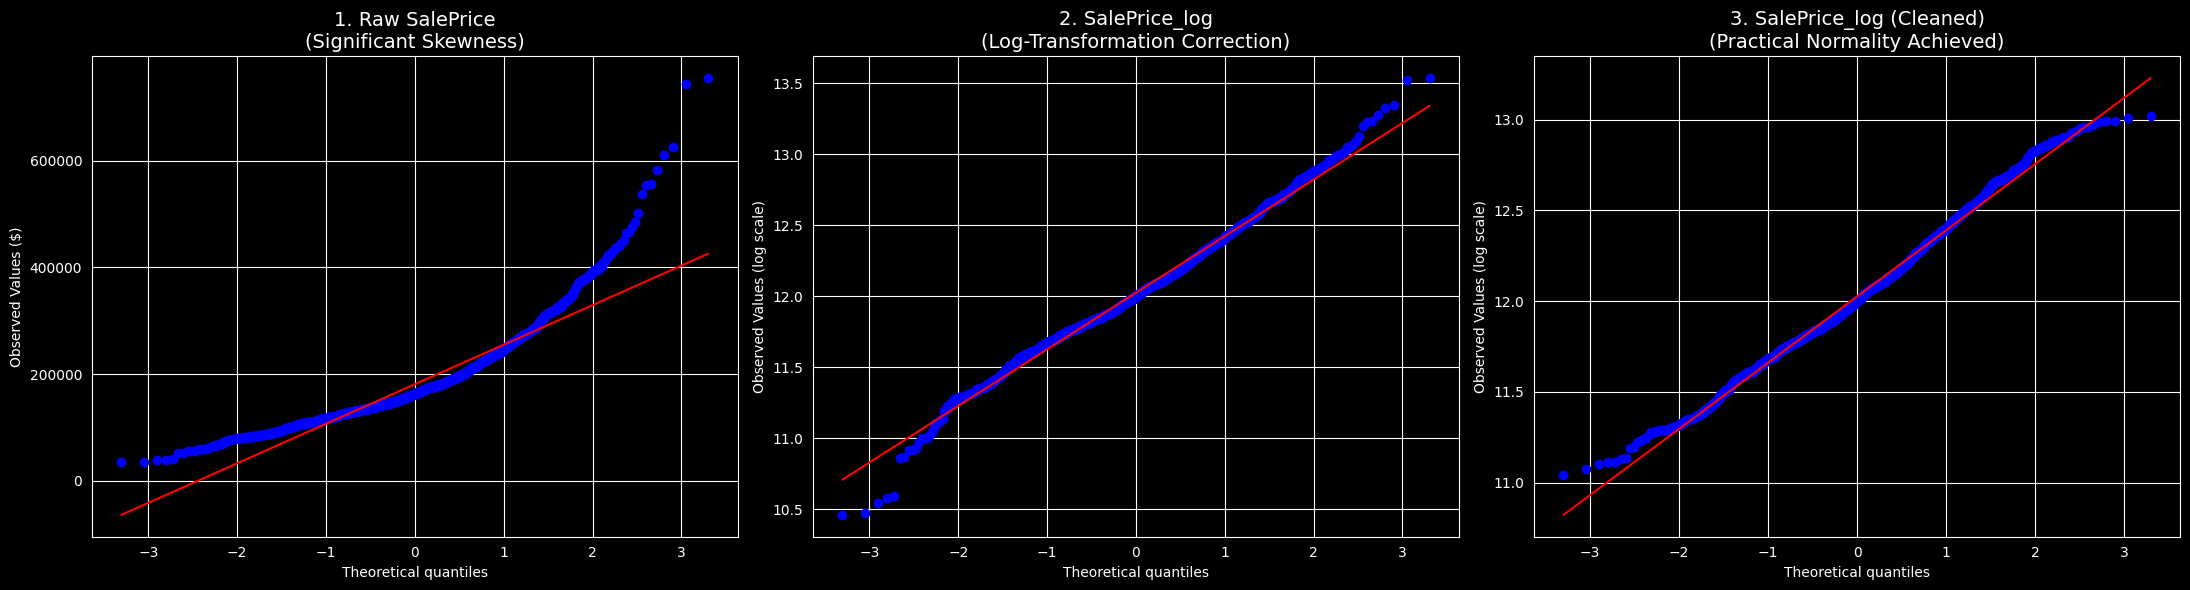

In [32]:
# Prepare the three versions of the target variable
y_raw = train['SalePrice']

# Calculate and remove outliers on the Log version (IQR Method)
Q1 = sales_price.quantile(0.25)
Q3 = sales_price.quantile(0.75)
IQR = Q3 - Q1
# Filtering: keeping only data within 1.5 * IQR
y_log_no_outliers = sales_price[~((sales_price < (Q1 - 1.5 * IQR)) | (sales_price > (Q3 + 1.5 * IQR)))]

# 2. Create the figure (1 row, 3 columns)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# --- Plot 1: Raw Data ---
stats.probplot(y_raw, dist="norm", plot=ax1)
ax1.set_title("1. Raw SalePrice\n(Significant Skewness)", fontsize=14)
ax1.set_ylabel("Observed Values ($)")

# --- Plot 2: Log Transformed ---
stats.probplot(sales_price, dist="norm", plot=ax2)
ax2.set_title("2. SalePrice_log\n(Log-Transformation Correction)", fontsize=14)
ax2.set_ylabel("Observed Values (log scale)")

# --- Plot 3: Log + No Outliers ---
stats.probplot(y_log_no_outliers, dist="norm", plot=ax3)
ax3.set_title("3. SalePrice_log (Cleaned)\n(Practical Normality Achieved)", fontsize=14)
ax3.set_ylabel("Observed Values (log scale)")

plt.tight_layout()
plt.show()

Comment :
- We can see that after the logarithmic transformation, data get closer to the quantile of a normal distribution proving that the transformation achieved the aforementioned goal of normalising the data.
- We can also see that the difference between the logarithmic SalePrice with and without outliers is small so we will keep the outliers until further evidence will prove them to be polluting for the overall results.

In [41]:
# Confidence interval for the mean of log price
alpha = 0.05
df = n - 1
t_crit = stats.t.ppf(1-alpha/2, df)
margin_error = t_crit * (std_sales_price/np.sqrt(n))
lower_limit = mean_sales_price - margin_error
upper_limit = mean_sales_price + margin_error
p = stats.t.cdf(t_crit, df)
print(f"Mean's confidence interval at 95% CI: [{lower_limit}, {upper_limit}]")

# CI for variance
a = stats.chi2.ppf(alpha/2, df)
b = stats.chi2.ppf(1-alpha/2, df)

# ((n-1)*sample_var)/b < pop_var < ((n-1)*sample_var)/a
var_lower_limit = (df*var_sales_price)/b
var_upper_limit = (df*var_sales_price)/a

print(f"Confidence Interval (95%) for the variance: [{var_lower_limit}, {var_upper_limit}]")

Mean's confidence interval at 95% CI: [12.003544164729277, 12.04455763748949]
Confidence Interval (95%) for the variance: [0.14858771791596836, 0.17180448306911694]


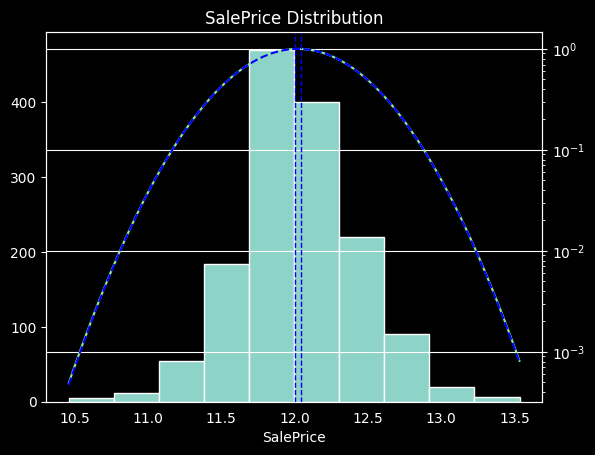

In [49]:
# PLOT
fig, ax = plt.subplots()
plt.hist(sales_price)
x = np.linspace(np.min(sales_price), np.max(sales_price), 1000)

t_dist = stats.t(df, loc=mean_sales_price, scale=std_sales_price)
t_but_normal = stats.norm(mean_sales_price, std_sales_price)

ax2 = ax.twinx()
ax.grid(False)
ax2.plot(x, t_dist.pdf(x), color='lightgreen', label="T Distribution")
ax2.plot(x, t_but_normal.pdf(x), color='blue', linestyle="--", label="Normal")
ax2.set_yscale('log')
ax.set_title('SalePrice Distribution')
ax.set_xlabel('SalePrice')
plt.axvline(lower_limit, color='blue', linestyle='--', linewidth=1)
plt.axvline(upper_limit, color='blue', linestyle='--', linewidth=1)
plt.show()

- The histogram, with the overlay of the Normal curve, shows that the data now follow a Normal distribution.
- The vertical blue lines mark the confidence interval of the mean.
- In the image, a Normal distribution and a T-Student distribution of `SalePrice_log` are overlapped to show that, with the size of this sample, the T-Distribution perfectly follows a Normal curve.


- **Hypothesis testing** — is the mean SalePrice significantly different from \$180,000?
- H0 : mean = \$180,000
- H1 : mean != \$180,000

In [47]:
# Transforming 180000 into log to make it comparable with SalePrice_log
h0_mean = np.log(180000)
print(f"H0 mean: {h0_mean}")

t_h0, p_h0 = stats.ttest_1samp(sales_price, h0_mean, alternative='two-sided')


if p_h0 < alpha:
    print(f"p-val < alpha: {p_h0 < alpha}")
    print("So we reject the null hypothesis")
else:
    print("Oh no, The null hypothesis was right!")

H0 mean: 12.100712129872347
p-val < alpha: True
So we reject the null hypothesis


#### Analysis of the numerical features

We can identify some key features as the ones that are the most correlated with `SalePrice_log`. A correlation coefficient bigger than 0.6 or smaller than -0.6 suggest a strong association with the compared variable.

In [76]:
correlations = train.corr(numeric_only=True)['SalePrice_log'].sort_values(ascending=False)


key_features = []
for feature in correlations.index:
    print(f'- {feature} : {correlations[feature]:.3f}')
    if correlations[feature] >= 0.6 and feature not in ["SalePrice", "SalePrice_log"]:
        key_features.append(feature)


- SalePrice_log : 1.000
- SalePrice : 0.948
- OverallQual : 0.817
- GrLivArea : 0.701
- GarageCars : 0.681
- GarageArea : 0.651
- TotalBsmtSF : 0.612
- 1stFlrSF : 0.597
- FullBath : 0.595
- YearBuilt : 0.587
- YearRemodAdd : 0.566
- TotRmsAbvGrd : 0.534
- Fireplaces : 0.489
- BsmtFinSF1 : 0.372
- WoodDeckSF : 0.334
- OpenPorchSF : 0.321
- 2ndFlrSF : 0.319
- HalfBath : 0.314
- LotArea : 0.257
- BsmtFullBath : 0.236
- BsmtUnfSF : 0.222
- BedroomAbvGr : 0.209
- ScreenPorch : 0.121
- PoolArea : 0.070
- MoSold : 0.057
- 3SsnPorch : 0.055
- BsmtFinSF2 : 0.005
- BsmtHalfBath : -0.005
- Id : -0.018
- MiscVal : -0.020
- OverallCond : -0.037
- YrSold : -0.037
- LowQualFinSF : -0.038
- MSSubClass : -0.074
- KitchenAbvGr : -0.148
- EnclosedPorch : -0.149


In [77]:
print('Features with a correlation >= 0.6:')

for feature in key_features:
    print(f'- {feature} : {correlations[feature]:.3f}')

Features with a correlation >= 0.6:
- OverallQual : 0.817
- GrLivArea : 0.701
- GarageCars : 0.681
- GarageArea : 0.651
- TotalBsmtSF : 0.612


Commentary on the correlation results:
- The most positively correlated features with SalePrice are `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea` and `TotalBsmtSF`. This makes sense since **these features are related to the quality** and **size of the house**, which are important factors in determining its price.
- There are **no features that are strongly negatively** correlated with SalePrice, which suggests that there are no features in the database which will strongly negatively affect the SalePrince.


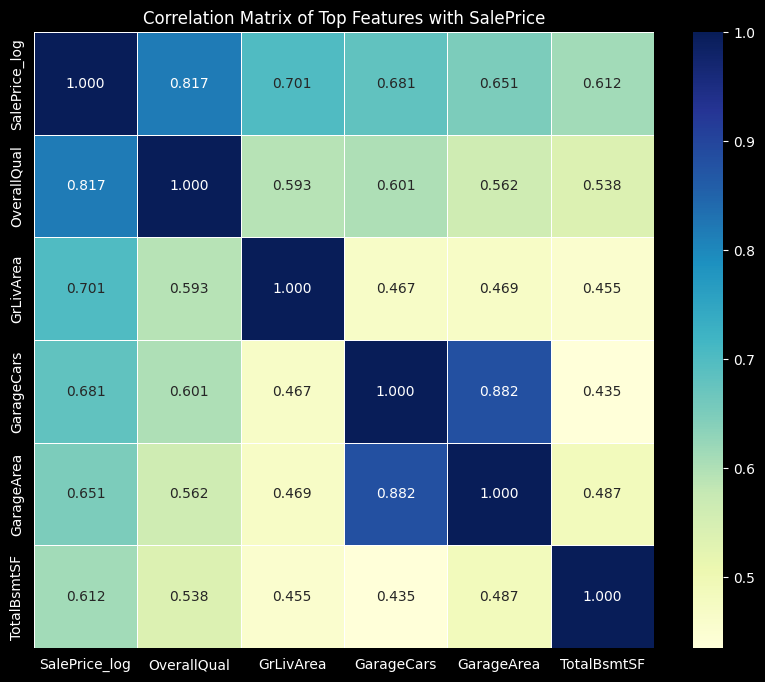

In [80]:
# Correlation

top_corr = train[["SalePrice_log"]+key_features].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(top_corr, annot=True, cmap='YlGnBu', fmt=".3f", linewidths=0.5)

plt.title("Correlation Matrix of Top Features with SalePrice")
plt.show()

Commentary on the correlation matrix:
- `GarageCars` and `GarageArea` are highly correlated with each other (0.88), which makes sense since they both measure the size of the garage. If a garage is big, it can contains more cars. So we could consider keeping only one of them in our model to avoid multicollinearity issues.


In [83]:
#general descriptive statistics for the key features
stats_summary = train[key_features].agg(['mean', 'var', 'std']).T

stats_summary.columns = ['Mean', 'Variance', 'Standard Deviation']
print(stats_summary)

                    Mean       Variance  Standard Deviation
OverallQual     6.099315       1.912679            1.382997
GrLivArea    1515.463699  276129.633363          525.480383
GarageCars      1.767123       0.558480            0.747315
GarageArea    472.980137   45712.510229          213.804841
TotalBsmtSF  1057.429452  192462.361709          438.705324


Commentary

- `OverallQual`: The mean of 6.1/10 indicates that the overall material and finishing of the house is generally ‘Above average’ with a relatively low degree of variation (standard deviation = 1.38).
- `GrLivArea`: The average living area is 1'515 square feet, but the high standard deviation of 525 indicates a wide range of sizes.
- `GarageCars`: With an average of 1.77 and a standard deviation 0.75, suggests that a garage can contain between 1 and 3.
- `GarageArea`: The average garage area is 473 square feet. The variance of 213 confirms the variation of "GarageCars".
- `TotalBsmtSF`: The basement averages 1'057 square feet with a standard deviation of 438, suggesting that also this variable can vary quite a lot.

---
## Part 2: ANOVA — Finding Significant Features

Use ANOVA to determine which of the following **10 features** have a statistically significant effect on the transformed SalePrice. 

**Given features (10):**

| # | Feature | Levels | Description |
|---|---|---|---|
| 1 | `OverallQual` | 1–10 | Overall material and finish quality |
| 2 | `ExterQual` | Po, Fa, TA, Gd, Ex | Exterior material quality |
| 3 | `BsmtQual` | None, Po, Fa, TA, Gd, Ex | Basement height quality |
| 4 | `KitchenQual` | Po, Fa, TA, Gd, Ex | Kitchen quality |
| 5 | `FireplaceQu` | None, Po, Fa, TA, Gd, Ex | Fireplace quality |
| 6 | `CentralAir` | N, Y | Central air conditioning |
| 7 | `LotShape` | IR3, IR2, IR1, Reg | General shape of property |
| 8 | `LandSlope` | Sev, Mod, Gtl | Slope of property |
| 9 | `MoSold` | 1–12 | Month sold |
| 10 | `YrSold` | 2006–2010 | Year sold |

**Tasks:**
1. Extract these features into a dataframe and run **one-way ANOVA** on each
2. Identify which features are significant (p < 0.05)
3. Run a **two-way ANOVA** to test for interaction effects between pairs of significant features
4. Summarize: which features and interactions are significant?

---
## Part 3: 2^k Factorial Design

Pick k binary (or binarized) factors from the significant features found in Part 2 and apply a factorial design analysis. For example you could binarize ordinal features into High/Low groups and study their joint effects.

**Tasks:**
- Select k factors (e.g. k=2 or k=3) and define High/Low levels
- Compute group means for all 2^k combinations
- Analyze main effects and interaction effects
- Visualize with interaction plots

---
## Part 4: Parametric Regression

Build a regression model using only the **significant ordinal features** identified by ANOVA (Part 2) plus the **2 numerical features**: `GrLivArea` and `TotalBsmtSF`.

**Tasks:**
- Encode ordinal features numerically (map quality levels to integers)
- Fit a linear regression model (OLS)
- Analyze the model: R², coefficient significance, residual plots
- Optionally try regularized regression (Ridge, Lasso) and compare
- Apply ANOVA on the regression model to assess factor contributions

---
## Part 5: Non-Parametric Model (Neural Network)

Build a neural network regression model using **all** available features to predict SalePrice. This is also the model that produces your `submission.csv` for Kaggle scoring.

**Tasks:**
- Preprocess all features: handle missing values, encode categoricals, scale numerics
- Build and train a neural network (e.g. `sklearn.neural_network.MLPRegressor` or PyTorch)
- Evaluate on training data (RMSE, R²) and analyze residuals
- Generate predictions for the test set and save as `submission.csv`

**Important:** The Kaggle RMSE score is evaluated on the predictions from this model.